# Week 7 — Parallel Execution

## Learning Goals

In this notebook we will learn:

- What parallel execution means
- How multiple nodes can run from the same node
- How their results are combined
- How this applies to multi-agent workflows

In [3]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END


In [4]:
class State(TypedDict):
    question: str
    web_result: str
    document_result: str
    final_answer: str

In [5]:
def planner_node(state: State):
    print("Planner node is running...")
    
    return {}

In [6]:
def web_search_node(state: State):
    print("Web search node is running...")
    
    return {
        "web_result": (
            f"Web research results for: {state['question']}"
        )
    }

In [7]:
def document_research_node(state: State):
    print("Document research running...")

    return {
        "document_result": (
            f"Document research results for: {state['question']}"
        )
    }

In [8]:
def final_answer_node(state: State):
    print("Final answer node running...")

    answer = (
        f"Question: {state['question']}\n\n"
        f"Web Research:\n{state['web_result']}\n\n"
        f"Document Research:\n{state['document_result']}"
    )

    return {
        "final_answer": answer
    }

In [9]:
graph = StateGraph(State)

graph.add_node("planner", planner_node)
graph.add_node("web_search", web_search_node)
graph.add_node("document_research", document_research_node)
graph.add_node("final_answer", final_answer_node)

In [10]:
graph.add_edge(START, "planner")
graph.add_edge("planner", "web_search")
graph.add_edge("planner", "document_research")
graph.add_edge("web_search", "final_answer")
graph.add_edge("document_research", "final_answer")
graph.add_edge("final_answer", END)

In [11]:
app = graph.compile()

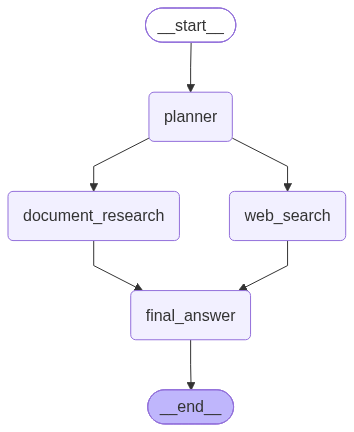

In [12]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [13]:
result = app.invoke({
    "question": "What is the capital of India?",
    "web_result": "",
    "document_result": "",
    "final_answer": ""
})

result

Planner node is running...
Document research running...
Web search node is running...
Final answer node running...


{'question': 'What is the capital of India?',
 'web_result': 'Web research results for: What is the capital of India?',
 'document_result': 'Document research results for: What is the capital of India?',
 'final_answer': 'Question: What is the capital of India?\n\nWeb Research:\nWeb research results for: What is the capital of India?\n\nDocument Research:\nDocument research results for: What is the capital of India?'}